In [1]:
#2021.08.18. WED
#Team_밥믈리에

#00. 패키지 호출
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings 

#00-1. warning message ignore 
warnings.filterwarnings(action='ignore')

#00-2. 사전변수 정의하기. 
RANGE = [2, 3, 4, 5, 6, 7, 8]


In [2]:
#01. 데이터셋 호출 및 전처리하기. 
#(1) 데이터셋 불러오기
cultivar_dataset = pd.read_excel('../data/nlp/cultivar_indicator_scaling_02.xlsx')

#(2) 데이터셋의 cultivar 컬럼 인덱스로 설정하기. 
cultivar_dataset.rename(columns={'Unnamed: 0':'cultivar'}, inplace=True)
cultivar_dataset.set_index('cultivar', inplace=True)

#(3) 결과 확인하기. 
cultivar_dataset

,고소하다,고슬하다,꼬들하다,달다,딱딱하다,부드럽다,질다,쫀득하다,찰지다,촉촉하다,탱탱하다,푸석하다
cultivar,,,,,,,,,,,,
count_고시히카리,2.291559,0.634386,0.336613,1.450026,0.103573,0.504920,0.297773,2.485759,3.029518,0.996893,0.893320,0.893320
count_골드퀸,36.137667,0.191205,0.191205,2.485660,0.191205,0.191205,0.382409,1.529637,2.676864,0.573614,0.191205,0.764818
count_밀키퀸,6.382979,0.000000,0.000000,2.127660,0.000000,0.000000,0.000000,0.000000,4.255319,0.000000,0.000000,2.127660
count_삼광,2.609042,0.557658,0.219080,1.274646,0.258913,0.477992,0.219080,1.792472,2.927704,0.517825,0.597491,1.234814
count_새청무,4.705882,0.588235,0.000000,1.176471,0.000000,0.000000,0.588235,2.352941,2.941176,2.352941,0.588235,1.176471
count_신동진,2.881967,0.381437,0.370841,1.229074,0.339055,0.434414,0.307268,1.631702,3.411740,0.879424,1.250265,1.504556
count_영호진미,2.215509,0.604230,0.369251,0.704935,0.503525,0.839208,0.402820,2.651897,4.330312,0.738503,0.570661,2.450487
count_오대,1.887621,0.351185,0.241440,1.141352,0.241440,0.285338,0.307287,1.887621,2.963126,0.614574,0.680421,1.602283
count_일품,3.184713,0.254777,0.382166,1.019108,0.127389,0.382166,0.254777,1.401274,3.566879,0.764331,0.127389,1.656051


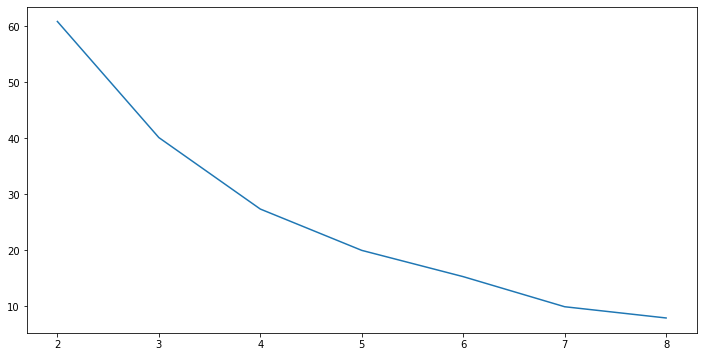

In [3]:
#02-1. k-means 모델 적용 전, 최적 k 값 파악을 위한 엘보우포인트 파악하기.
#(1) k 값에 따른 inertia(관성) 값 수집하기. 
inertia_list = []

for k in RANGE :
    kmeans_model = KMeans(n_clusters=k, random_state=2021)
    kmeans_model.fit(cultivar_dataset)
    inertia = kmeans_model.inertia_
    inertia_list.append(inertia)

#(2) 시각화하기.
plt.figure(figsize=(12,6))
plt.plot(RANGE, inertia_list)
plt.show()

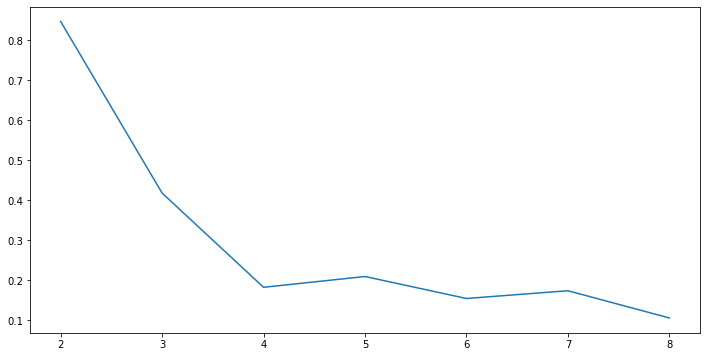

In [4]:
#02-2. k-means 모델 적용 전, 최적 k값 파악을 위한 실루엣계수 파악하기. 
#(1) k 값에 따른 silhouette_score 값 수집하기. 
silh_score_list = []

for k in RANGE :
    kmeans_model = KMeans(n_clusters=k, random_state=2021)
    silh_score = silhouette_score(cultivar_dataset.iloc[:,:12], kmeans_model.fit_predict(cultivar_dataset))
    silh_score_list.append(silh_score)

#(2) 시각화하기. 
plt.figure(figsize=(12,6))
plt.plot(RANGE, silh_score_list)
plt.show()

In [5]:
#MEMO. 최적 k값은 2로 결정함. 

In [6]:
#03. k-means 모델로 군집화하기. 
#(1) k-means 모델 객체 정의하기. 
kmeans_model = KMeans(n_clusters=2)

#(2) 데이터셋에 군집 번호 컬럼 추가하기. 
cultivar_dataset['cluster_num'] = kmeans_model.fit_predict(cultivar_dataset)

#(4) 행 별 실루엣 계수 컬럼 추가하기. 
#cultivar_dataset['silhouette_coef'] = silhouette_samples(cultivar_dataset.iloc[:,:12], cultivar_dataset['cluster_num'])

#(5) 처리 결과 확인하기. 
cultivar_dataset

,고소하다,고슬하다,꼬들하다,달다,딱딱하다,부드럽다,질다,쫀득하다,찰지다,촉촉하다,탱탱하다,푸석하다,cluster_num
cultivar,,,,,,,,,,,,,
count_고시히카리,2.291559,0.634386,0.336613,1.450026,0.103573,0.504920,0.297773,2.485759,3.029518,0.996893,0.893320,0.893320,0
count_골드퀸,36.137667,0.191205,0.191205,2.485660,0.191205,0.191205,0.382409,1.529637,2.676864,0.573614,0.191205,0.764818,1
count_밀키퀸,6.382979,0.000000,0.000000,2.127660,0.000000,0.000000,0.000000,0.000000,4.255319,0.000000,0.000000,2.127660,0
count_삼광,2.609042,0.557658,0.219080,1.274646,0.258913,0.477992,0.219080,1.792472,2.927704,0.517825,0.597491,1.234814,0
count_새청무,4.705882,0.588235,0.000000,1.176471,0.000000,0.000000,0.588235,2.352941,2.941176,2.352941,0.588235,1.176471,0
count_신동진,2.881967,0.381437,0.370841,1.229074,0.339055,0.434414,0.307268,1.631702,3.411740,0.879424,1.250265,1.504556,0
count_영호진미,2.215509,0.604230,0.369251,0.704935,0.503525,0.839208,0.402820,2.651897,4.330312,0.738503,0.570661,2.450487,0
count_오대,1.887621,0.351185,0.241440,1.141352,0.241440,0.285338,0.307287,1.887621,2.963126,0.614574,0.680421,1.602283,0
count_일품,3.184713,0.254777,0.382166,1.019108,0.127389,0.382166,0.254777,1.401274,3.566879,0.764331,0.127389,1.656051,0


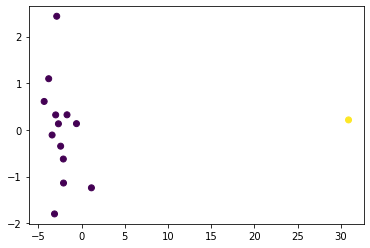

In [7]:
#04. 군집 시각화하기. 
#(1) 주성분 분석을 통해 2차원으로 축소하기. 
pca = PCA(n_components=2, random_state=2021)
cultivar_dataset_pca = pca.fit_transform(cultivar_dataset.iloc[:,:-1])
cultivar_dataset_pca = pd.DataFrame(cultivar_dataset_pca, columns=['PC1','PC2'])
cultivar_dataset_pca['cluster_num'] = kmeans_model.fit_predict(cultivar_dataset_pca)

#(2) PCA 처리값을 기반으로 시각화하기. 
plt.scatter(x=cultivar_dataset_pca['PC1'], y=cultivar_dataset_pca['PC2'], c=cultivar_dataset_pca['cluster_num'])
plt.show()

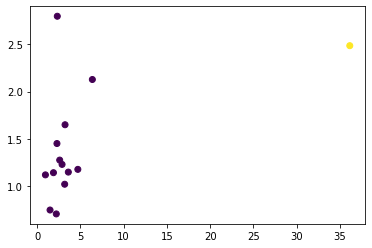

In [8]:
#05. 
#(1)
plt.fig
plt.scatter(x=cultivar_dataset['고소하다'], y=cultivar_dataset['달다'], c=cultivar_dataset['cluster_num'])
plt.show()

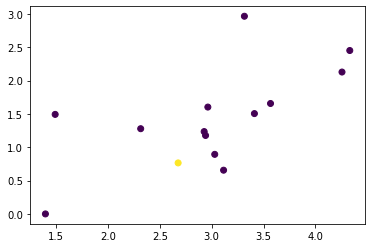

In [9]:
#(2)
plt.scatter(x=cultivar_dataset['찰지다'], y=cultivar_dataset['푸석하다'], c=cultivar_dataset['cluster_num'])
plt.show()